In [2]:
import matplotlib.pyplot as plt
import zipfile
with zipfile.ZipFile('/content/data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

100%|██████████| 2583/2583 [00:01<00:00, 1852.68it/s]


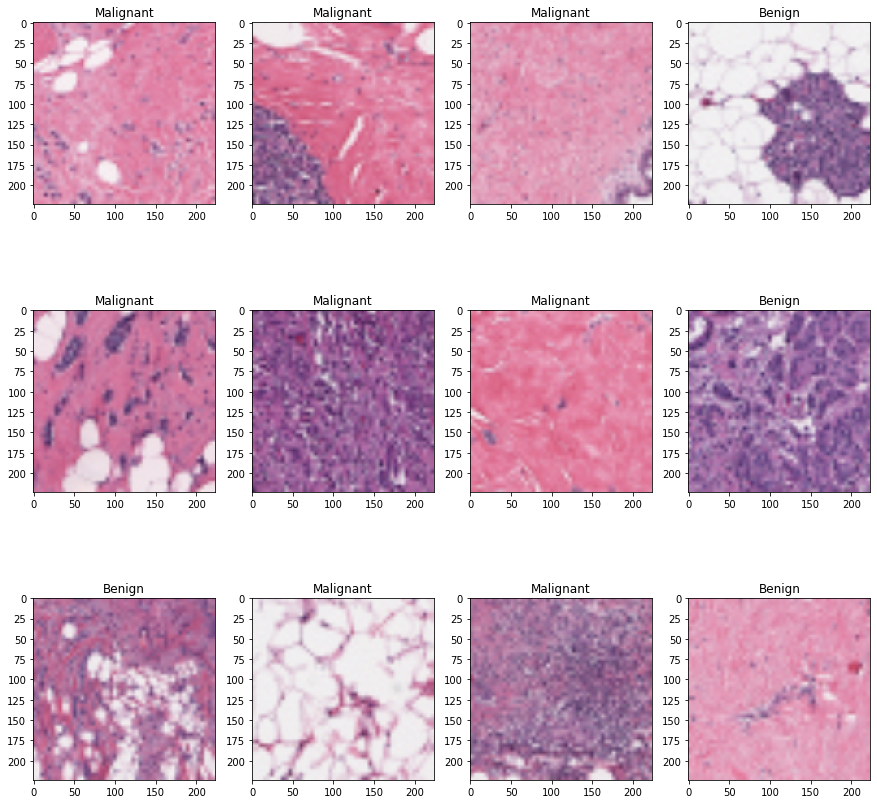

74850304/74836368 [==============================] - 1s 0us/step


/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet201 (Functional)    (None, 7, 7, 1920)        18321984  
                                                                 
 global_average_pooling2d (G  (None, 1920)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1920)              0         
                                                                 
 batch_normalization (BatchN  (None, 1920)             7680      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 2)                 3842      
                                                                 
Total params: 18,333,506
Trainable params: 18,100,610
No

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:168: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.


Epoch 1/5
237/237 [==============================] - 237s 748ms/step - loss: 0.4973 - accuracy: 0.7958 - val_loss: 0.4657 - val_accuracy: 0.8486 - lr: 1.0000e-04
Epoch 2/5
237/237 [==============================] - 162s 682ms/step - loss: 0.4509 - accuracy: 0.8140 - val_loss: 0.3759 - val_accuracy: 0.8496 - lr: 1.0000e-04
Epoch 3/5
237/237 [==============================] - 162s 683ms/step - loss: 0.4177 - accuracy: 0.8300 - val_loss: 0.4661 - val_accuracy: 0.8538 - lr: 1.0000e-04
Epoch 4/5
237/237 [==============================] - 162s 683ms/step - loss: 0.3892 - accuracy: 0.8387 - val_loss: 0.3105 - val_accuracy: 0.8864 - lr: 1.0000e-04
Epoch 5/5
237/237 [==============================] - 163s 688ms/step - loss: 0.3825 - accuracy: 0.8445 - val_loss: 0.3283 - val_accuracy: 0.8885 - lr: 1.0000e-04
Saved model to disk


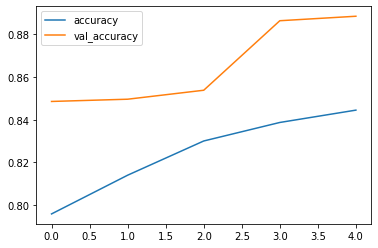

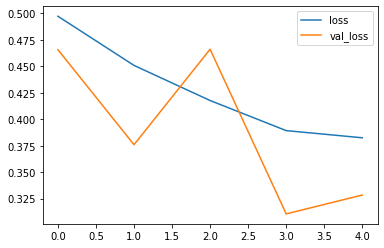

In [3]:
import json
import math
import os

import cv2
from PIL import Image
import numpy as np
from keras import layers
from tensorflow.keras.applications import ResNet50,MobileNet, DenseNet201, InceptionV3, NASNetLarge, InceptionResNetV2, NASNetMobile
from keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from keras.preprocessing.image import ImageDataGenerator
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
import scipy
from tqdm import tqdm
import tensorflow as tf
from keras import backend as K
import gc
from functools import partial
from sklearn import metrics
from collections import Counter
import json
import itertools


%matplotlib inline



#Transfer 'jpg' images to an array IMG
def Dataset_loader(DIR, RESIZE, sigmaX=10):
    IMG = []
    read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))
    for IMAGE_NAME in tqdm(os.listdir(DIR)):
        PATH = os.path.join(DIR,IMAGE_NAME)
        _, ftype = os.path.splitext(PATH)
        if ftype == ".png":
            img = read(PATH)
           
            img = cv2.resize(img, (RESIZE,RESIZE))
           
            IMG.append(np.array(img))
    return IMG

benign_train = np.array(Dataset_loader('train/Normal',224))
malign_train = np.array(Dataset_loader('train/Cancer',224))
benign_test = np.array(Dataset_loader('train/Normal',224))
malign_test = np.array(Dataset_loader('train/Cancer',224))




# Create labels
benign_train_label = np.zeros(len(benign_train))
malign_train_label = np.ones(len(malign_train))
benign_test_label = np.zeros(len(benign_test))
malign_test_label = np.ones(len(malign_test))

# Merge data 
X_train = np.concatenate((benign_train, malign_train), axis = 0)
Y_train = np.concatenate((benign_train_label, malign_train_label), axis = 0)
X_test = np.concatenate((benign_test, malign_test), axis = 0)
Y_test = np.concatenate((benign_test_label, malign_test_label), axis = 0)

# Shuffle train data
s = np.arange(X_train.shape[0])
np.random.shuffle(s)
X_train = X_train[s]
Y_train = Y_train[s]

# Shuffle test data
s = np.arange(X_test.shape[0])
np.random.shuffle(s)
X_test = X_test[s]
Y_test = Y_test[s]

# To categorical
Y_train = to_categorical(Y_train, num_classes= 2)
Y_test = to_categorical(Y_test, num_classes= 2)


x_train, x_val, y_train, y_val = train_test_split(
    X_train, Y_train, 
    test_size=0.2, 
    random_state=11
)


# # Display first 15 images of moles, and how they are classified
w=60
h=40
fig=plt.figure(figsize=(15, 15))
columns = 4
rows = 3

for i in range(1, columns*rows +1):
    ax = fig.add_subplot(rows, columns, i)
    if np.argmax(Y_train[i]) == 0:
        ax.title.set_text('Benign')
    else:
        ax.title.set_text('Malignant')
    plt.imshow(x_train[i], interpolation='nearest')
plt.show()


BATCH_SIZE = 16

# Using original generator
train_generator = ImageDataGenerator(
        zoom_range=2,  # set range for random zoom
        rotation_range = 90,
        horizontal_flip=True,  # randomly flip images
        vertical_flip=True,  # randomly flip images
    )


def build_model(backbone, lr=1e-4):
    model = Sequential()
    model.add(backbone)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.5))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(2, activation='softmax'))
    
    
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(lr=lr),
        metrics=['accuracy']
    )
    
    return model

K.clear_session()
gc.collect()

resnet = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


 


model = build_model(resnet ,lr = 1e-4)
model.summary()

# Learning Rate Reducer
learn_control = ReduceLROnPlateau(monitor='val_acc', patience=5,
                                  verbose=1,factor=0.2, min_lr=1e-7)

# Checkpoint
filepath="weights.best.hdf5"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max')

history = model.fit_generator(
    train_generator.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=x_train.shape[0] / BATCH_SIZE,
    epochs=5,
    validation_data=(x_val, y_val),
    callbacks=[learn_control, checkpoint]
)


with open('history.json', 'w') as f:
    json.dump(str(history.history), f)

history_df = pd.DataFrame(history.history)
history_df[['accuracy', 'val_accuracy']].plot()

history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss']].plot()

model.save_weights("weights.best.hdf5")
print("Saved model to disk")


ENTER INPUT IMAGE NAME: 2.png


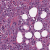

[1.3744735e-06, 0.99999857]
Cancer


In [5]:
model.load_weights("weights.best.hdf5")
#Y_val_pred = model.predict(x_val)
#accuracy_score(np.argmax(y_val, axis=1), np.argmax(Y_val_pred, axis=1))
import cv2
CATEGORIES = ["Normal","Cancer"]
image =input("ENTER INPUT IMAGE NAME: ") #your image path
from google.colab.patches import cv2_imshow
x=cv2.imread(image,1)
cv2_imshow(x)
IMG = []
read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))
img = read(image)           
img = cv2.resize(img, (224,224))
IMG.append(np.array(img))
prediction = model.predict(np.array(IMG))
prediction = list(prediction[0])
print(prediction)
print(CATEGORIES[prediction.index(max(prediction))])